In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Loading the data

In [2]:
df = pd.read_csv('IHSG_full_history_1990.csv', skiprows=2)

df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()

# 2. Defining the period of dates

In [3]:
presidents = [
    {"name": "Suharto", "start": "1990-04-06", "end": "1998-05-21", "color": "#d4af37"},
    {"name": "Habibie", "start": "1998-05-21", "end": "1999-10-20", "color": "#8ebf42"},
    {"name": "Gus Dur", "start": "1999-10-20", "end": "2001-07-23", "color": "#2e7d32"},
    {"name": "Megawati", "start": "2001-07-23", "end": "2004-10-20", "color": "#c62828"},
    {"name": "SBY", "start": "2004-10-20", "end": "2014-10-20", "color": "#1565c0"},
    {"name": "Jokowi", "start": "2014-10-20", "end": "2024-10-20", "color": "#b71c1c"},
    {"name": "Prabowo", "start": "2024-10-20", "end": "2026-04-26", "color": "#ef6c00"}
]

# 3. Plotting

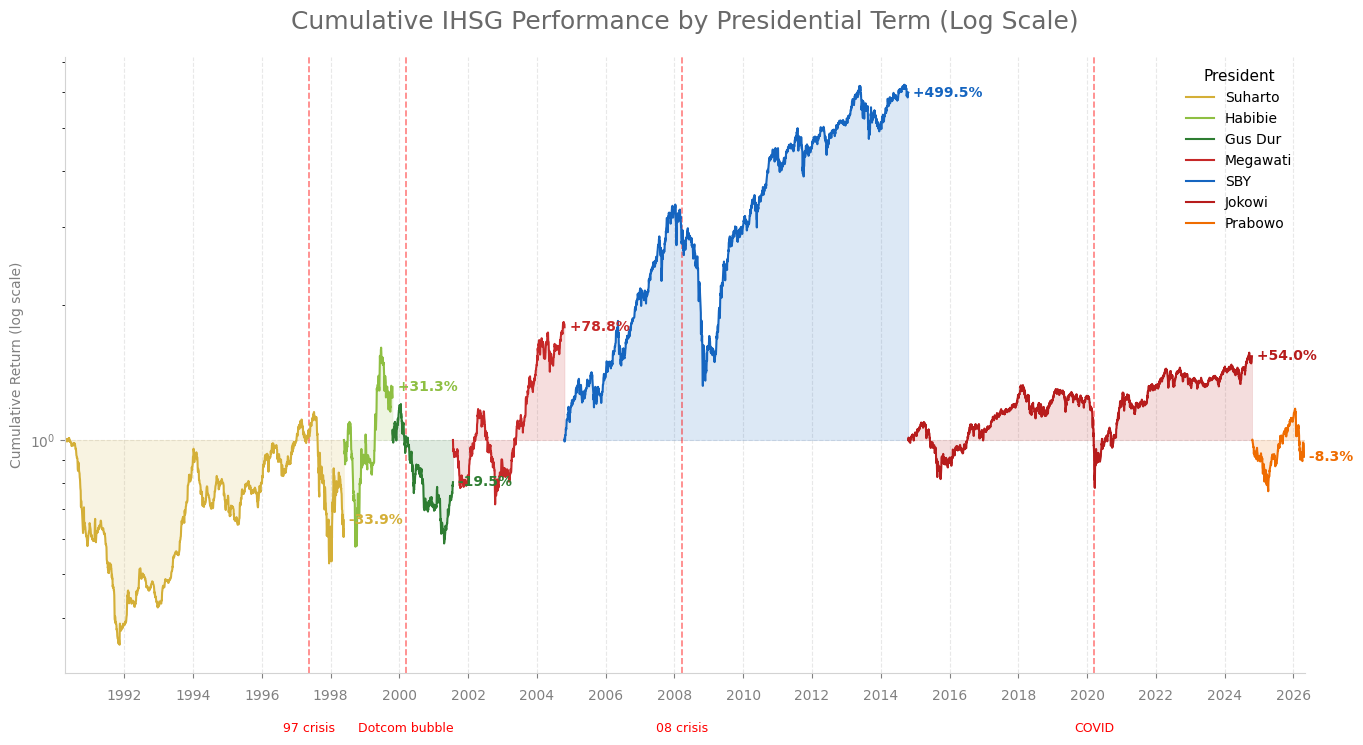

In [4]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(16, 8), facecolor='white')
plt.style.use('bmh')
ax.set_facecolor('white')
ax.set_title('Cumulative IHSG Performance by Presidential Term (Log Scale)', fontsize=18, pad=20, color='dimgray')

for p in presidents:
    term_data = df.loc[p['start']:p['end']].copy()
    
    if not term_data.empty:
        initial_price = term_data['Close'].iloc[0]
        term_data['Return'] = term_data['Close'] / initial_price
        
        ax.plot(term_data.index, term_data['Return'], color=p['color'], lw=1.5, label=p['name'])
        ax.fill_between(term_data.index, 1, term_data['Return'], color=p['color'], alpha=0.15)
        
        final_val = term_data['Return'].iloc[-1]
        final_pct = (final_val - 1) * 100
        ax.text(term_data.index[-1], final_val, f" {final_pct:+.1f}%", 
                color=p['color'], fontsize=10, fontweight='bold', va='center')

crisis_events = [
    ("1997-05-14", "97 crisis"),
    ("2000-03-10", "Dotcom bubble"),
    ("2008-03-16", "08 crisis"),
    ("2020-03-20", "COVID")
]

initial_price = df['Close'].iloc[0]

for date_str, event_name in crisis_events:
    event_date = pd.to_datetime(date_str)

    closest_idx = df.index.get_indexer([event_date], method='nearest')[0]
    closest_date = df.index[closest_idx]
    
    if closest_date >= df.index[0] and closest_date <= df.index[-1]:
        ax.axvline(closest_date, color='red', alpha=0.5, lw=1.2, linestyle='--', zorder=1)
        ax.text(closest_date, -0.08, event_name,
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', color='red', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_yscale('log')
ax.set_ylabel('Cumulative Return (log scale)', color='gray')
ax.legend(title='President', frameon=False, fontsize=10, title_fontsize=11)
ax.grid(True, color='lightgray', alpha=0.5, linestyle='--', zorder=0)
ax.set_xlim(df.index.min(), df.index.max())

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', colors='gray', labelsize=10, labelrotation=0, pad=8)
ax.tick_params(axis='y', colors='gray', labelsize=10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('lightgray')
ax.set_axisbelow(True)
